# Histogram-Based Speech/Silence Segmentation

**Student:** Mai Nguyen Dat Nguyen  
**Algorithm:** Histogram-Based Method  
**Reference:** Giannakopoulos (2014)

This notebook presents the implementation and experimental evaluation of a histogram-based speech/silence segmentation method.


## 1. Objective

The objective is to segment each test speech signal into **speech** and **silence** regions and evaluate the detected speech boundaries against the provided ground truth.

The experiment uses four test signals and reports:

- detected speech boundaries;
- intermediate histogram-based thresholding results;
- Mean Absolute Error (MAE);
- Root Mean Square Error (RMSE);
- missing and extra detected boundaries.


## 2. Method Overview

The implemented processing pipeline is:

1. Frame the audio signal using a **25 ms frame length** and **10 ms frame shift**.
2. Extract two features:
   - **Log Short-Time Energy (log STE)**
   - **Spectral Centroid**
3. Construct a histogram for each feature.
4. Smooth each histogram using a **Gaussian filter**.
5. Detect local maxima in the smoothed histogram.
6. Select the two dominant maxima as **M1** and **M2** when two peaks are available.
7. Calculate the threshold using:

   `T = (W × M1 + M2) / (W + 1)`

8. Classify a frame as speech when **both** feature conditions are satisfied.
9. Merge silence intervals shorter than **200 ms**.
10. Extract the final speech boundaries.
11. Compare the detected boundaries with the ground truth.

## 3. Implementation

The notebook uses the project's shared modules for audio loading, ground-truth reading, evaluation, plotting, and the Histogram algorithm. The notebook acts as the experimental runner for the Histogram method.


In [1]:
import sys
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project root
PROJECT_ROOT = Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config.parameters import (
    TESTING_DIR,
    FRAME_LENGTH_MS,
    FRAME_SHIFT_MS,
    MIN_SILENCE_MS,
    load_trained_parameters
)

from src.common.audio import load_audio
from src.common.lab_reader import read_lab, get_speech_boundaries
from src.common.evaluation import evaluate_boundaries
from src.histogram.algorithm import HistogramAlgorithm

### Parameter roles

The **25 ms frame length** and **10 ms frame shift** are fixed by the assignment. They determine how the continuous waveform is divided into short-time analysis frames.

The **200 ms minimum silence duration** is also fixed by the assignment. After frame-level classification, a silence gap shorter than this duration is merged into the surrounding speech region.

The remaining Histogram parameters are algorithm parameters obtained during the training stage. They are kept unchanged when evaluating the test signals.


## 4. Experimental Parameters

The following parameters are fixed according to the project requirements.


In [2]:
#Fixed parameters
print("Fixed parameters")
print(f"Frame length : {FRAME_LENGTH_MS} ms")
print(f"Frame shift  : {FRAME_SHIFT_MS} ms")
print(f"Min silence  : {MIN_SILENCE_MS} ms")

Fixed parameters
Frame length : 25 ms
Frame shift  : 10 ms
Min silence  : 200 ms


In [3]:
#Load trained parameters

trained_params = load_trained_parameters()

hist_params = trained_params["histogram"]

print("Histogram trained parameters")
for key, value in hist_params.items():
    print(f"{key}: {value}")

Histogram trained parameters
histogram_bins: 50
smoothing_sigma: 2.0
W: 3.0
peak_prominence: 0.02
peak_distance: 3
training_mae_ms: 25.0
training_rmse_ms: 31.92
feature_representation: log_STE + spectral_centroid


### Why training parameters are separated from fixed parameters

The assignment fixes the time resolution and minimum silence duration, but the Histogram method still requires parameters for constructing and analyzing the feature histograms. These include the number of bins, Gaussian smoothing strength, threshold weight, and peak-detection settings.

The training stage searches for a parameter combination using the training signals. The selected values are then saved in `trained_parameters.json` and reused for the test set. This prevents the test results from being manually tuned for individual test files.


### Trained Histogram Parameters

These parameters were obtained during training and are used unchanged for the test-set evaluation.

- `histogram_bins`: number of histogram bins.
- `smoothing_sigma`: Gaussian smoothing parameter.
- `W`: weighting factor in the threshold formula.
- `peak_prominence`: minimum prominence for local-peak detection.
- `peak_distance`: minimum distance between detected peaks.


## 5. Test Dataset

The test set contains four WAV files. Their corresponding `.lab` files provide the ground-truth speech boundaries.

The test files are used for the final evaluation.


In [4]:
#4 test files

wav_files = sorted(Path(TESTING_DIR).glob("*.wav"))

print(f"Number of test files: {len(wav_files)}")

for wav_path in wav_files:
    print("-", wav_path.name)

Number of test files: 4
- phone_F2.wav
- phone_M2.wav
- studio_F2.wav
- studio_M2.wav


### Processing one test signal

The algorithm operates at the **frame level** first. Each frame receives two feature values: one describing its signal energy and one describing its spectral distribution. The two feature sequences are then converted into speech/silence decisions.

The `.lab` file is used only as the **ground truth** for evaluation. It is not used to determine the test-time thresholds.


## 6. Run the Histogram Algorithm

Each test signal is processed using the same trained parameter set. For each file, the notebook:

- loads the audio signal;
- runs the Histogram algorithm;
- reads the ground-truth `.lab` file;
- extracts ground-truth boundaries;
- evaluates the detected boundaries using MAE and RMSE.



In [5]:
#4 test results
algorithm = HistogramAlgorithm()

results = {}

for wav_path in wav_files:
    print("=" * 60)
    print(f"Processing: {wav_path.name}")

    signal, fs = load_audio(str(wav_path))

    result = algorithm.predict(
        signal,
        fs,
        hist_params
    )

    lab_path = wav_path.with_suffix(".lab")

    intervals = read_lab(str(lab_path))
    gt_boundaries_s = get_speech_boundaries(intervals)

    detected_boundaries_s = [
        b / 1000.0
        for b in result["boundaries_ms"]
    ]

    evaluation = evaluate_boundaries(
        detected_boundaries_s,
        gt_boundaries_s
    )

    results[wav_path.stem] = {
        "wav_path": wav_path,
        "signal": signal,
        "fs": fs,
        "result": result,
        "evaluation": evaluation,
        "gt_boundaries_s": gt_boundaries_s,
    }

    print(f"MAE  : {evaluation['mae_ms']:.2f} ms")
    print(f"RMSE : {evaluation['rmse_ms']:.2f} ms")

Processing: phone_F2.wav
MAE  : 90.00 ms
RMSE : 99.53 ms
Processing: phone_M2.wav
  Using fallback: threshold = median of feature values.
  This fallback is NOT the original Giannakopoulos method.
MAE  : 40.00 ms
RMSE : 54.83 ms
Processing: studio_F2.wav
  Using fallback: threshold = median of feature values.
  This fallback is NOT the original Giannakopoulos method.
  Using fallback: threshold = median of feature values.
  This fallback is NOT the original Giannakopoulos method.
MAE  : 15.00 ms
RMSE : 15.21 ms
Processing: studio_M2.wav
MAE  : 17.49 ms
RMSE : 20.15 ms


### How the evaluation metrics are interpreted

For every test signal, the detected boundary times are matched with the nearest unused ground-truth boundaries. The error of a matched pair is measured in milliseconds.

- **MAE (Mean Absolute Error):** average absolute boundary error.
- **RMSE (Root Mean Square Error):** similar to MAE, but larger errors have a stronger influence.
- **Missing:** ground-truth boundaries for which no detected boundary was matched.
- **Extra:** detected boundaries that do not correspond to a ground-truth boundary.

Therefore, a good segmentation should have small MAE/RMSE and as few Missing/Extra boundaries as possible.


## 7. Quantitative Results

The table summarizes the boundary detection performance for all four test signals.

**MAE** measures the average absolute boundary error.  
**RMSE** gives greater weight to larger boundary errors.

`Missing` indicates ground-truth boundaries that were not matched by detected boundaries. `Extra` indicates additional detected boundaries.


In [6]:
#Result table
summary_rows = []

for name, item in results.items():
    evaluation = item["evaluation"]

    summary_rows.append({
        "Test File": name,
        "MAE (ms)": evaluation["mae_ms"],
        "RMSE (ms)": evaluation["rmse_ms"],
        "Matched": evaluation["num_matched"],
        "Missing": evaluation["num_missing"],
        "Extra": evaluation["num_extra"],
    })

results_df = pd.DataFrame(summary_rows)

results_df

,Test File,MAE (ms),RMSE (ms),Matched,Missing,Extra
0,phone_F2,90.000000,99.530146,2,0,4
1,phone_M2,40.000000,54.829280,2,0,4
2,studio_F2,15.000000,15.205975,2,0,0
3,studio_M2,17.494331,20.150723,2,0,0


In [7]:
#Average result

print(f"Average MAE  : {results_df['MAE (ms)'].mean():.2f} ms")
print(f"Average RMSE : {results_df['RMSE (ms)'].mean():.2f} ms")

Average MAE  : 40.62 ms
Average RMSE : 47.43 ms


### Why two features are used

**Log STE** represents the short-time signal energy. Speech frames generally contain more acoustic activity than silent frames, so their energy distribution can help separate the two classes. The logarithm compresses the large dynamic range of energy values.

**Spectral Centroid** describes where the spectral energy of a frame is concentrated along the frequency axis. It provides information that is different from energy alone.

Using both features makes the decision more restrictive: a frame is labeled as speech only if it passes **both** thresholds.


## 8. Intermediate Histogram Results

The Histogram method determines thresholds from the distribution of feature values.

After Gaussian smoothing, local maxima are detected. When two suitable peaks are available, they provide **M1** and **M2**, which are then used to calculate:

`T = (W × M1 + M2) / (W + 1)`

A frame is classified as speech only when **both feature decisions** are positive.


In [8]:
#Show M1, M2 and threshold

for name, item in results.items():

    diag = item["result"]["diagnostics"]

    print("=" * 60)
    print(name)

    print("\nEnergy / Log STE")
    print(f"M1        : {diag['energy_M1']}")
    print(f"M2        : {diag['energy_M2']}")
    print(f"Threshold : {diag['energy_threshold']}")

    print("\nSpectral Centroid")
    print(f"M1        : {diag['centroid_M1']}")
    print(f"M2        : {diag['centroid_M2']}")
    print(f"Threshold : {diag['centroid_threshold']}")

phone_F2

Energy / Log STE
M1        : -4.5003907828668455
M2        : -2.832232719098526
Threshold : -4.083351266924765

Spectral Centroid
M1        : 2317.947129876673
M2        : 3611.473291168084
Threshold : 2641.3286701995257
phone_M2

Energy / Log STE
M1        : -5.1878076123476955
M2        : -2.5362795339139583
Threshold : -4.524925592739261

Spectral Centroid
M1        : 1470.6248821510685
M2        : None
Threshold : 1397.3455163536448
studio_F2

Energy / Log STE
M1        : -1.727401659817743
M2        : None
Threshold : -5.090400867353732

Spectral Centroid
M1        : 2535.75
M2        : None
Threshold : 2180.699533154185
studio_M2

Energy / Log STE
M1        : -6.540584799809393
M2        : -2.193433539878003
Threshold : -5.453796984826545

Spectral Centroid
M1        : 1952.8957315750863
M2        : 3097.2555242944986
Threshold : 2238.985679754939


### Meaning of M1, M2 and the threshold

In a smoothed feature histogram, a **local maximum (peak)** represents a concentration of frames with similar feature values. When two meaningful peaks are available, the algorithm uses their feature locations as **M1** and **M2**.

The threshold is placed between these two characteristic values using the weighting factor `W`:

`T = (W × M1 + M2) / (W + 1)`

With `W > 1`, the threshold is positioned closer to `M1`. The exact position therefore depends on both the two detected feature groups and the trained value of `W`.

If the histogram does not provide two suitable peaks, the current implementation cannot apply the original two-peak calculation. It therefore uses the median as a fallback and reports this explicitly in the output.


### Interpretation of Peak Detection

The number of detected peaks depends on the distribution of feature values.

For some test signals, only one peak is detected. In the current implementation, the threshold then falls back to the **median of the feature values**. This fallback is explicitly reported by the implementation and is **not part of the original Giannakopoulos method**.

The fallback is retained as part of the implemented experimental system rather than modifying the test results manually.


### How to read the histogram figures

The **x-axis** represents the feature value, while the **y-axis** represents the number of frames falling into each histogram bin. The raw histogram shows the original distribution.

Gaussian smoothing reduces small fluctuations so that broader distribution patterns are easier to identify. The detected local maxima are then used to estimate the characteristic feature groups and determine the threshold.

These plots are intermediate diagnostic results: they explain **how the threshold was obtained**, rather than being the final speech/silence output.


## 9. Histogram Visualization

The following figures show the intermediate thresholding process for the representative test signal `studio_F2`.

Each figure contains the original histogram, the Gaussian-smoothed histogram, detected local peaks, M1/M2 when available, and the resulting threshold.


In [9]:
#draw-histogram function

def plot_feature_histogram(diag, feature_type, title):
    if feature_type == "energy":
        histogram = diag["energy_histogram"]
        smoothed = diag["energy_histogram_smoothed"]
        bin_edges = diag["energy_histogram_bins"]
        peaks = diag["energy_peaks"]
        M1 = diag["energy_M1"]
        M2 = diag["energy_M2"]
        threshold = diag["energy_threshold"]
        xlabel = "Log Short-Time Energy"
    else:
        histogram = diag["centroid_histogram"]
        smoothed = diag["centroid_histogram_smoothed"]
        bin_edges = diag["centroid_histogram_bins"]
        peaks = diag["centroid_peaks"]
        M1 = diag["centroid_M1"]
        M2 = diag["centroid_M2"]
        threshold = diag["centroid_threshold"]
        xlabel = "Spectral Centroid"

    centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    plt.figure(figsize=(10, 5))

    plt.bar(
        centers,
        histogram,
        width=np.diff(bin_edges),
        alpha=0.35,
        label="Histogram"
    )

    plt.plot(
        centers,
        smoothed,
        linewidth=2,
        label="Gaussian-smoothed histogram"
    )

    if len(peaks) > 0:
        plt.scatter(
            centers[peaks],
            smoothed[peaks],
            s=50,
            label="Detected peaks"
        )

    if M1 is not None:
        plt.axvline(M1, linestyle="--", linewidth=1.5, label=f"M1 = {M1:.2f}")

    if M2 is not None:
        plt.axvline(M2, linestyle="--", linewidth=1.5, label=f"M2 = {M2:.2f}")

    if threshold is not None:
        plt.axvline(threshold, linestyle="-", linewidth=2, label=f"Threshold = {threshold:.2f}")

    plt.xlabel(xlabel)
    plt.ylabel("Frequency")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

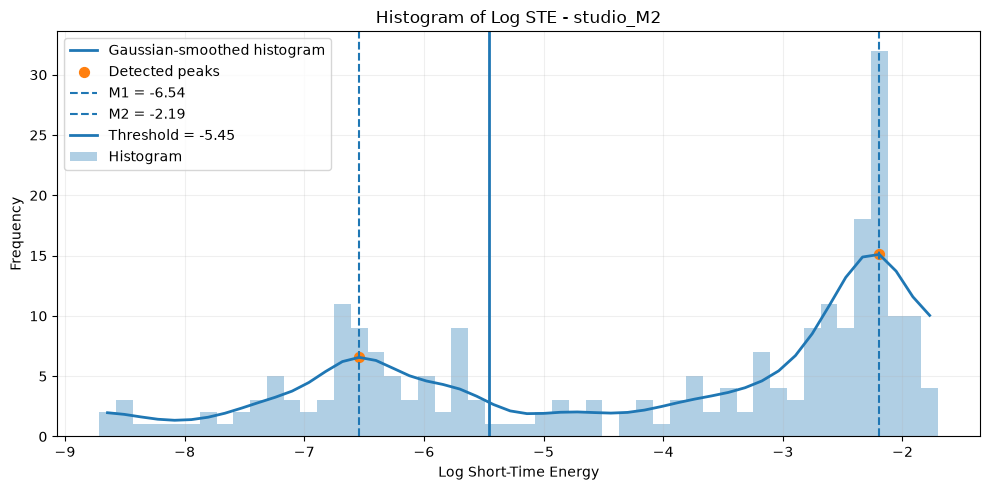

In [10]:
#draw Histogram of Log STE - studio_M2

example_name = "studio_M2"
diag = results[example_name]["result"]["diagnostics"]

plot_feature_histogram(
    diag,
    "energy",
    f"Histogram of Log STE - {example_name}"
)


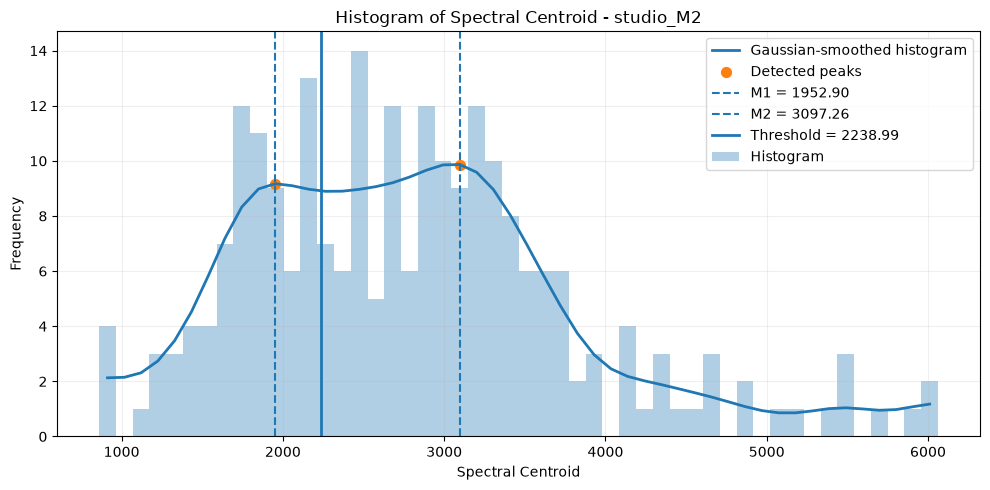

In [11]:
#Histogram Spectral Centroid of studio_M2

plot_feature_histogram(
    diag,
    "centroid",
    f"Histogram of Spectral Centroid - {example_name}"
)

### From frame decisions to final boundaries

After both feature thresholds are applied, the algorithm has a binary decision for each frame: speech or silence. Consecutive speech frames are grouped into speech segments.

The post-processing step then merges silence gaps shorter than **200 ms**, as required by the assignment. Finally, the transitions between speech and silence are converted into boundary times in milliseconds.

The final figure is therefore the result of the complete pipeline, not just the histogram thresholding stage.


## 10. Final Speech/Silence Segmentation

The following figure shows the final segmentation result for the representative test signal. Detected boundaries are compared with the ground-truth boundaries from the `.lab` file.


Saved to: results\histogram\studio_M2_notebook.png


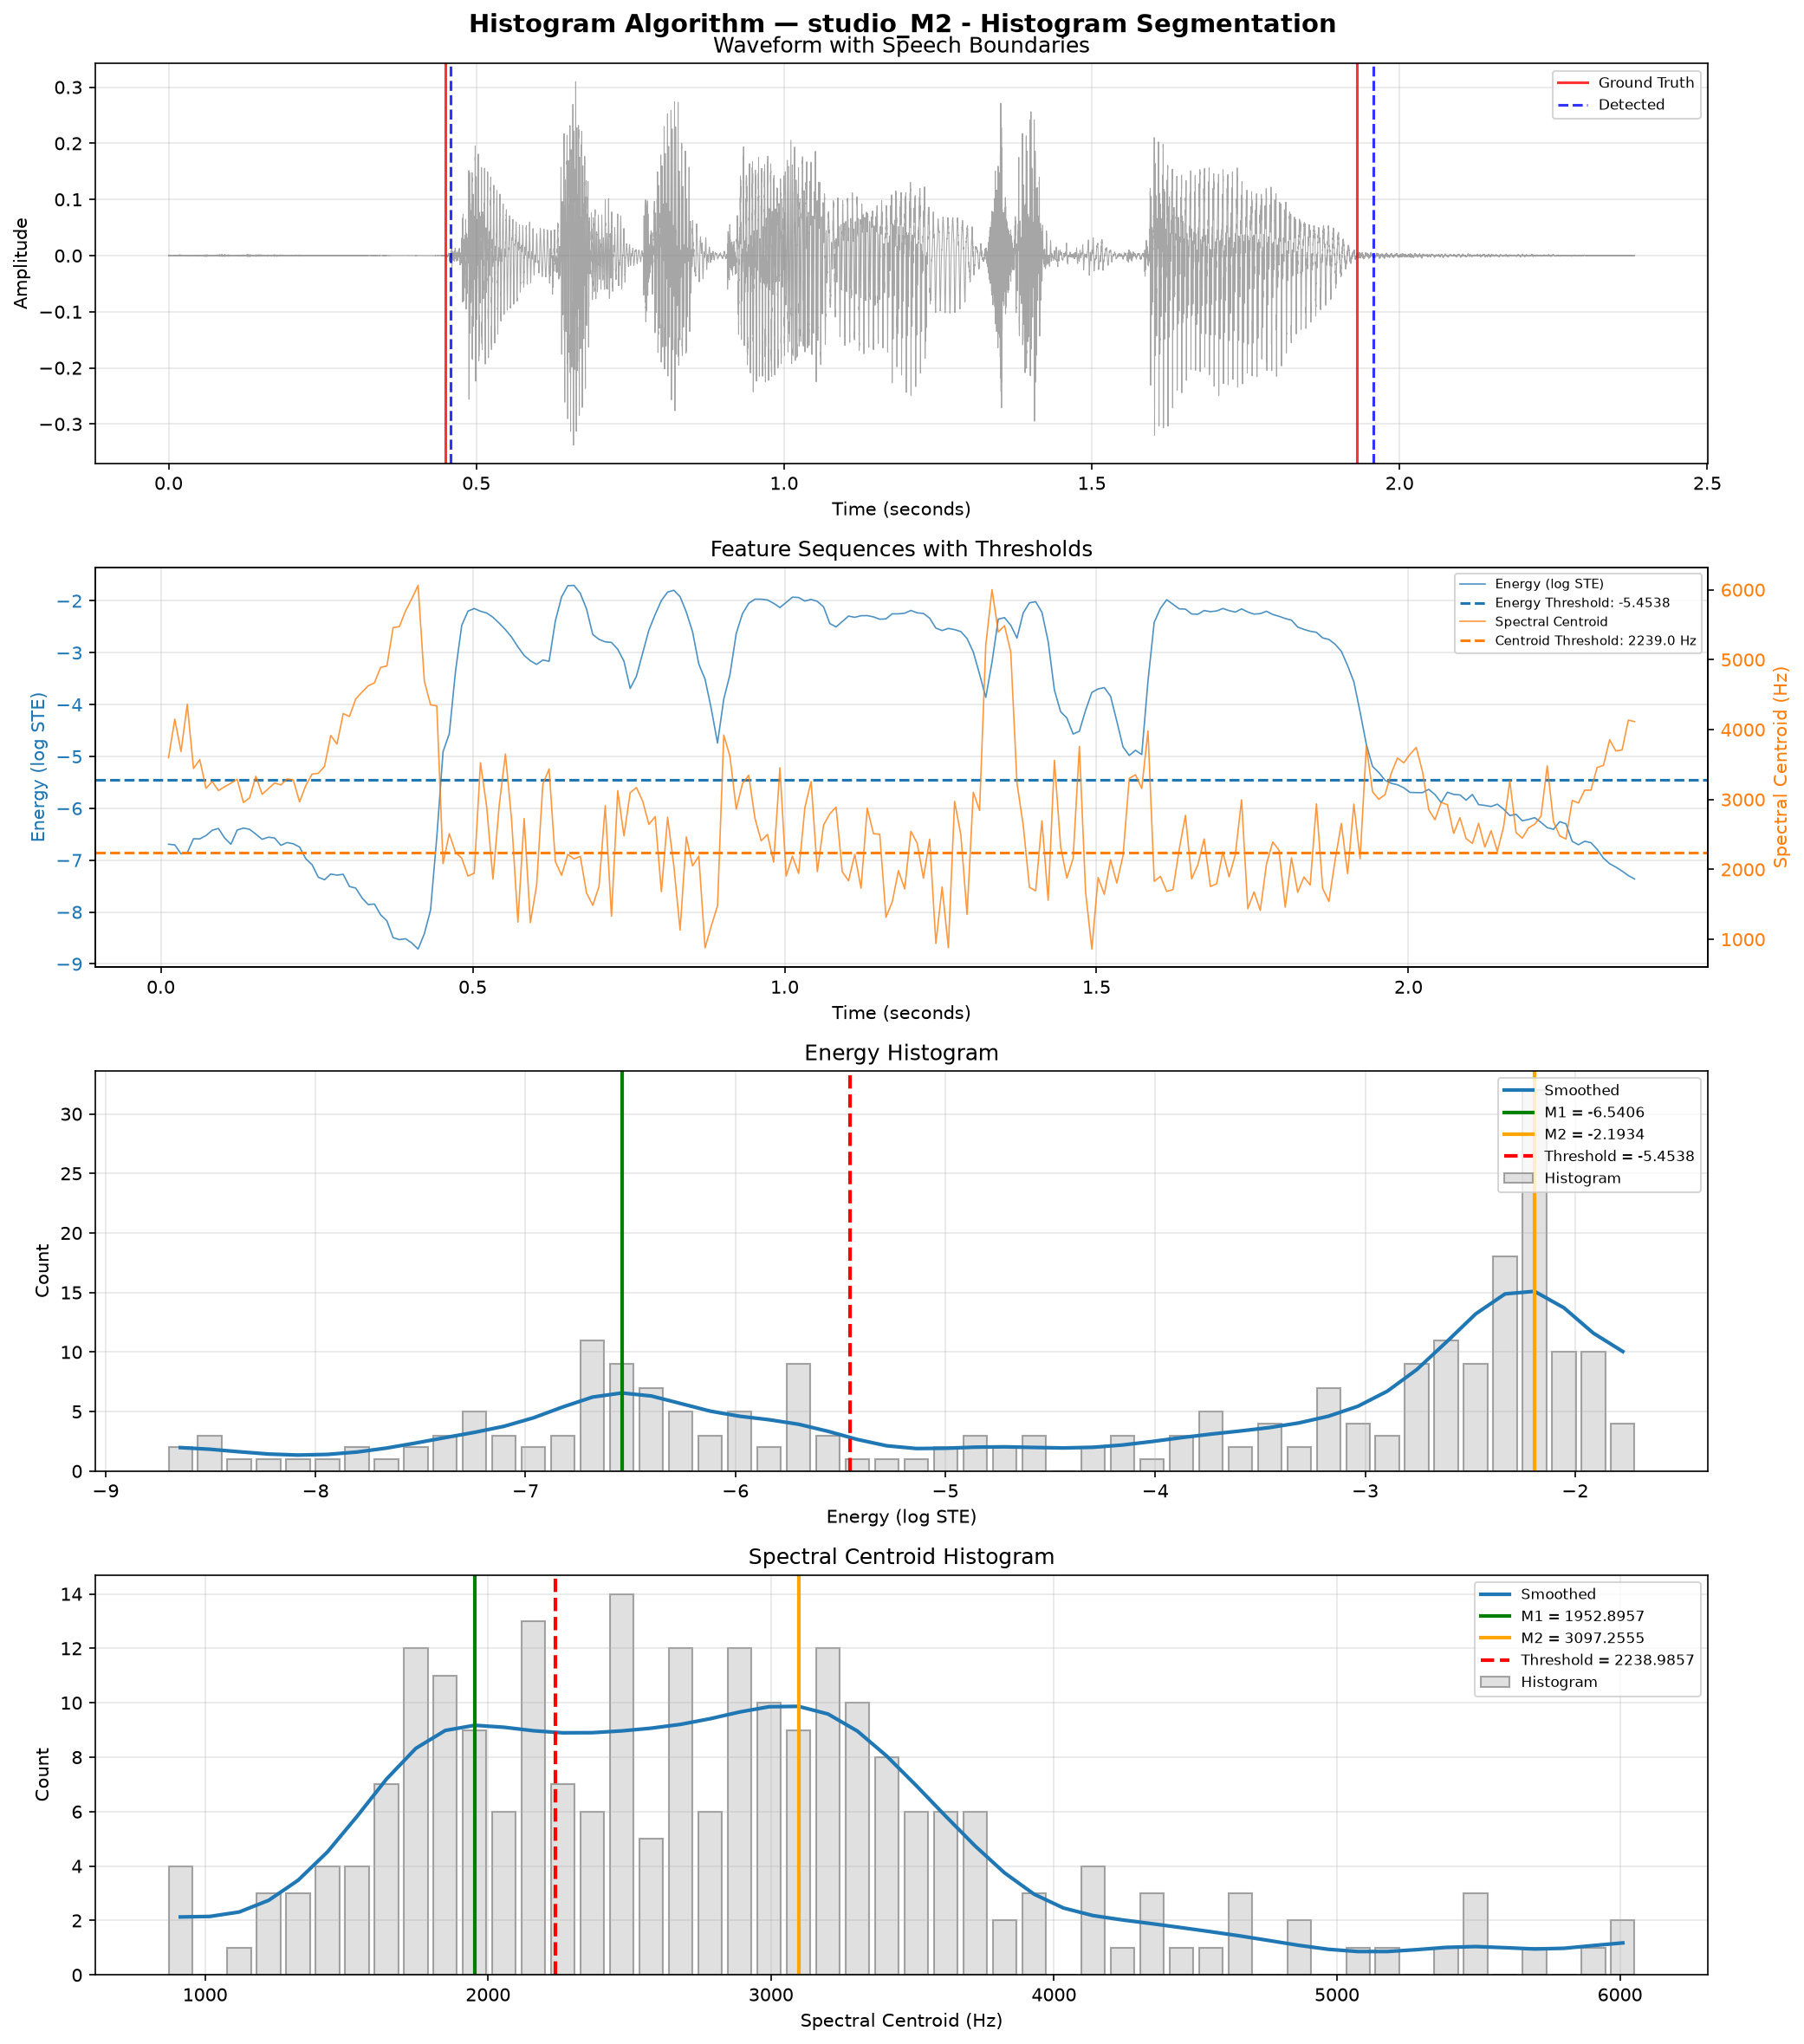

In [12]:
from IPython.display import Image, display
from pathlib import Path
from src.common.plotting import plot_algorithm_result

item = results[example_name]
output_path = Path("results") / "histogram" / f"{example_name}_notebook.png"
output_path.parent.mkdir(parents=True, exist_ok=True)

plot_algorithm_result(
    item["signal"],
    item["fs"],
    item["result"],
    item["gt_boundaries_s"],
    str(output_path),
    f"{example_name} - Histogram Segmentation"
)

plt.close('all')

print(f"Saved to: {output_path}")

display(Image(filename=str(output_path)))

### Interpreting the differences between recordings

The Histogram method is data-distribution based. It does not use a single universal energy value for every recording; instead, it estimates thresholds from the feature distributions of the signal being processed. Consequently, changes in microphone, recording environment, background noise, speaker characteristics, and spectral content can change the histogram shape and the resulting decisions.

In this experiment, the studio recordings have fewer extra boundaries, while the phone recordings generate several additional short speech/silence transitions. These extra detections contribute directly to the larger error values.

This is an experimental observation from the current test set, not a claim that every studio recording will always outperform every phone recording.


## 11. Discussion

The results show that the Histogram-based method performs differently depending on the recording characteristics.

For the two studio recordings, the detected boundaries are close to the ground truth and no extra boundaries are reported. The phone recordings produce more extra boundaries, which increases the MAE and RMSE.

This indicates that histogram-based thresholding is influenced by the statistical distribution of the extracted features. Phone recordings can produce feature distributions that are less clearly separated into speech and silence regions.

The experiment therefore demonstrates both the usefulness and the limitations of the Histogram-based approach.


### Main takeaway

The experiment confirms the complete operation of the Histogram-based approach: feature extraction, histogram construction, Gaussian smoothing, peak-based threshold estimation, dual-feature classification, post-processing, and boundary evaluation.

The results also show an important limitation: the quality of the final segmentation depends on how clearly the speech and silence characteristics are separated in the extracted feature distributions.


## 12. Conclusion

The Histogram-based speech/silence segmentation method was implemented and evaluated on four test signals.

The method combines **Log Short-Time Energy** and **Spectral Centroid**. Histograms of these features are smoothed using a Gaussian filter, local maxima are detected, and thresholds are calculated from the dominant feature distributions.

The final performance is evaluated using **MAE** and **RMSE** of the detected speech boundaries.

For the current test set, the average performance is:

- **Average MAE: 40.62 ms**
- **Average RMSE: 47.43 ms**

The experiment also shows that performance depends on the characteristics and recording conditions of the input signals.


### Submission note

The notebook contains the executable code together with the displayed experimental outputs, so the results can be inspected without waiting for a new execution during the presentation. The shared project source code remains outside the notebook according to the group's project structure.


## 13. Reproducibility Note

This notebook is intended to be submitted with its execution outputs already stored.

The WAV/LAB signal files and the Python virtual environment are **not included in the submission folder**, in accordance with the project submission requirement.
